In [17]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

In [18]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)

In [19]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",") # El separador es "," porque en el archivo .csv los valores están separados por coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar

In [20]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [21]:
# ================================================================================================================== #
# 4. ONE-HOT ENCODING (A las variables categóricas aplícales One-Hot Encoding, 
# y a las numéricas déjalas como están) #
# ================================================================================================================== #
 
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
])

In [22]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor

ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', StandardScaler(),
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [23]:
# ============================= #
# 5. MOSTRAR LA BASE CODIFICADA #
# ============================= #
 
X = df[cat_cols + features]
X_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_encoded_df = pd.DataFrame.sparse.from_spmatrix(X_encoded, columns=feature_names)
X_encoded_df.sample(20)

,cat__job_title_Backend Developer,cat__job_title_Business Analyst,cat__job_title_Cloud Engineer,cat__job_title_Cybersecurity Analyst,cat__job_title_Data Analyst,cat__job_title_Data Scientist,cat__job_title_DevOps Engineer,cat__job_title_Frontend Developer,cat__job_title_Machine Learning Engineer,cat__job_title_Product Manager,cat__job_title_Software Engineer,cat__education_level_Diploma,cat__education_level_High School,cat__education_level_Master,cat__education_level_PhD,cat__industry_Education,cat__industry_Finance,cat__industry_Government,cat__industry_Healthcare,cat__industry_Manufacturing,cat__industry_Media,cat__industry_Retail,cat__industry_Technology,cat__industry_Telecom,cat__company_size_Large,cat__company_size_Medium,cat__company_size_Small,cat__company_size_Startup,cat__location_Canada,cat__location_Germany,cat__location_India,cat__location_Netherlands,cat__location_Remote,cat__location_Singapore,cat__location_Sweden,cat__location_UK,cat__location_USA,cat__remote_work_No,cat__remote_work_Yes,num__experience_years,num__skills_count,num__certifications
101508,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0,-1.155895,0.365411,-0.874276
249094,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0.494109,1.642952,0.297732
58117,0,0,1.0,0,0,0,0,0,0,0,0,0,1.0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.319111,-0.182106,-0.874276
19775,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,1.484112,0.000399,-0.288272
215358,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,0,0,0,1.0,0,0,0,0,0,1.0,0,-1.650897,-1.277141,0.883737
41107,0,0,0,0,0,1.0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,-0.660894,-1.277141,1.469741
33913,0,0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,-0.990895,-0.729624,0.883737
4116,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,-0.660894,1.642952,-1.460281
217546,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,1.0,0,-0.330893,1.095434,-0.874276
54202,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,1.0,-0.660894,-1.094636,-1.460281


In [24]:
# ============================================= #
# 6. MOSTRAR LAS COLUMNAS DE LA BASE CODIFICADA #
# ============================================= #
X_encoded_df.columns.tolist()

['cat__job_title_Backend Developer',
 'cat__job_title_Business Analyst',
 'cat__job_title_Cloud Engineer',
 'cat__job_title_Cybersecurity Analyst',
 'cat__job_title_Data Analyst',
 'cat__job_title_Data Scientist',
 'cat__job_title_DevOps Engineer',
 'cat__job_title_Frontend Developer',
 'cat__job_title_Machine Learning Engineer',
 'cat__job_title_Product Manager',
 'cat__job_title_Software Engineer',
 'cat__education_level_Diploma',
 'cat__education_level_High School',
 'cat__education_level_Master',
 'cat__education_level_PhD',
 'cat__industry_Education',
 'cat__industry_Finance',
 'cat__industry_Government',
 'cat__industry_Healthcare',
 'cat__industry_Manufacturing',
 'cat__industry_Media',
 'cat__industry_Retail',
 'cat__industry_Technology',
 'cat__industry_Telecom',
 'cat__company_size_Large',
 'cat__company_size_Medium',
 'cat__company_size_Small',
 'cat__company_size_Startup',
 'cat__location_Canada',
 'cat__location_Germany',
 'cat__location_India',
 'cat__location_Netherlands

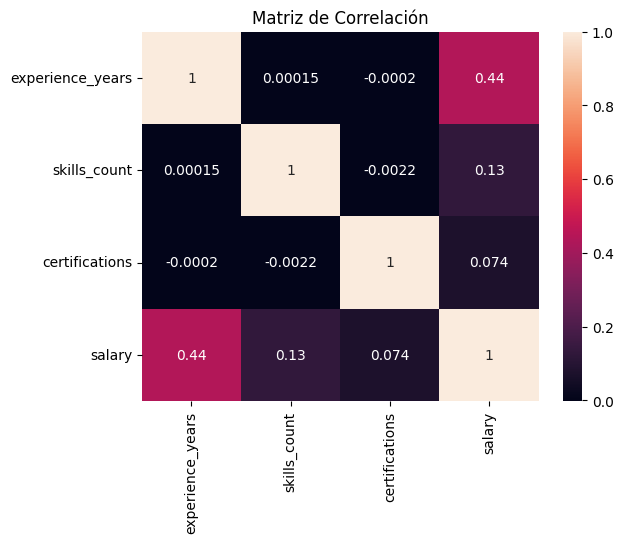

In [25]:
# ===================================================== #
# 7. ANÁLISIS DE CORRELACIÓN (Solo variables numéricas) #
# ===================================================== #

corr = df[features + [target]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Matriz de Correlación")
plt.show()

In [26]:
# ========================= #
# 8. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols] 
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
# ====================== #
# 9. MODELO DE REGRESIÓN #
# ====================== #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('regressor', LinearRegression())])

In [28]:
# ============== #
# 10. EVALUACIÓN #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)

MAE: 5436.096838454473
RMSE: 7125.522785614388
MAPE: 0.04136095010827766
MAPE(%): 4.136095010827765
R2: 0.9634690240598502


In [29]:
# ======================================== #
# 10.1. DATAFRAME CON RESULTADOS Y ERRORES # 
# ======================================== #

# Asegurar formatos
X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

# Construir DataFrame final
df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df

df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)

,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
21122,3,4,1,Backend Developer,PhD,Consulting,Enterprise,India,Yes,105459,110589.870808,-5130.870808,5130.870808
30743,8,13,5,Cybersecurity Analyst,Bachelor,Telecom,Enterprise,Canada,Yes,202792,196177.695032,6614.304968,6614.304968
30575,12,13,5,AI Engineer,High School,Telecom,Startup,Australia,Hybrid,143115,145240.745272,-2125.745272,2125.745272
7041,1,16,5,DevOps Engineer,Diploma,Technology,Enterprise,USA,Yes,187775,189577.604773,-1802.604773,1802.604773
15253,5,2,1,Data Scientist,Diploma,Government,Large,UK,Yes,136874,143631.999239,-6757.999239,6757.999239
14686,4,10,3,AI Engineer,Master,Healthcare,Startup,Singapore,Yes,147287,144836.535615,2450.464385,2450.464385
49010,15,11,1,Software Engineer,High School,Technology,Startup,UK,Hybrid,123516,133874.819119,-10358.819119,10358.819119
48662,12,11,3,Product Manager,Diploma,Retail,Small,Germany,Hybrid,148417,150587.194863,-2170.194863,2170.194863
45840,15,2,0,Backend Developer,PhD,Finance,Medium,Sweden,Hybrid,148696,147899.691834,796.308166,796.308166
39587,2,5,2,Cloud Engineer,Bachelor,Finance,Enterprise,Sweden,No,128764,138216.478585,-9452.478585,9452.478585


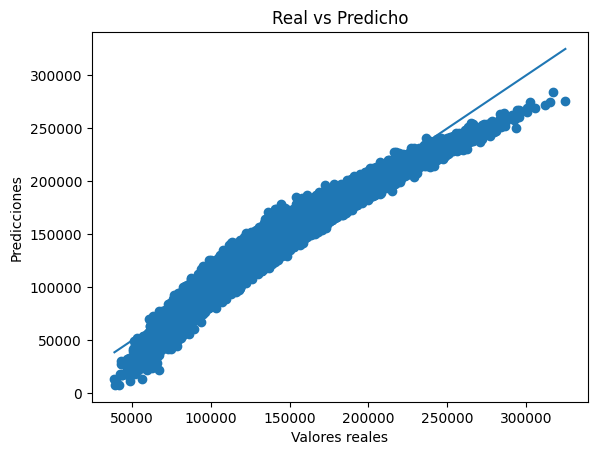

In [30]:
# ====================== #
# 10.2. REAL VS PREDICHO #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")

# Línea ideal
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)

plt.show()

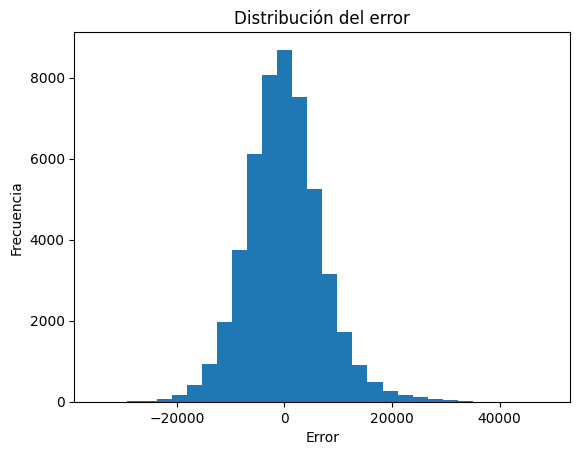

In [31]:
# ============================= #
# 10.3. DISTRIBUCIÓN DE ERRORES #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()